In [13]:
%matplotlib qt
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import cm
from random import randint
import math

In [2]:
def plotSL(x_S, y_S, line):
    fig, ax = plt.subplots()
    ax.scatter(x_S, y_S, color='blue', label='Data Points')
    ax.plot(line, color='red', linestyle='--', label='Trend Line')
    ax.set_xlabel('X-axis Label')
    ax.set_ylabel('Y-axis Label')
    ax.set_title('Scatter Plot with a Line')
    ax.legend()
    plt.show()
def plot3d(x, y, z):
    fig = plt.figure() 
    ax = fig.add_subplot(projection='3d')
    ax.scatter(x, y, z, c='r', marker='o') #

    # Set labels for the axes
    ax.set_xlabel('W Label')
    ax.set_ylabel('B Label')
    ax.set_zlabel('Cost Label')
    
    # Display the plot
    plt.show()
    

In [3]:
data = pd.read_csv("data.csv")

In [4]:
data.head()

,x,y
0,4.035535,4.014696
1,3.017795,0.643823
2,0.064315,0.048016
3,0.203297,0.098833
4,4.367375,1.313792


<Axes: xlabel='x', ylabel='y'>

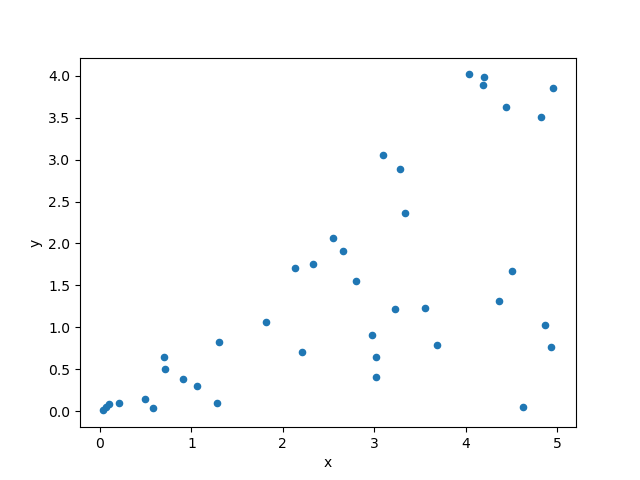

In [5]:
data.plot.scatter(x='x', y='y')

In [6]:
def cost(m, b, x, y):
    sum = 0
    for i, j in zip(x, y):
        sum += ((m * i + b) - j)**2
    return sum/(2*len(y))
def _costM(m, b, x, y):
    sum = 0
    for i, j in zip(x, y):
        sum += (m * i + b - j)*i
    return sum/(len(y))
def _costB(m, b, x, y):
    sum = 0
    for i, j in zip(x, y):
        sum += (m * i + b - j)
    return sum/(len(y))

In [20]:
m = randint(1, 100)
b = randint(1, 100)
step = 0.1

In [21]:
cost(m, b, data.x, data.y)

62455.067903743104

In [22]:
for i in range(10000):
    temp_m = step*_costM(m, b,data.x,data.y)
    temp_b = step*_costB(m,b,data.x,data.y)
    m -= temp_m
    b -= temp_b

In [23]:
plotSL(data.x, data.y, np.array([m, b]))
cost(m, b, data.x, data.y)

0.4767117771534589

In [26]:
# Make data
rng = np.random.default_rng()
X = rng.integers(1, 1000, size=5)
Y = rng.integers(1, 1000, size=5)
X, Y = np.meshgrid(X, Y)
Z = cost(X, Y, data.x, data.y)

# Set up the 3D plot
fig, ax = plt.subplots(subplot_kw={"projection": "3d"})
ax.set_xlabel('X-axis Label')
ax.set_ylabel('Y-axis Label')
ax.set_zlabel('Z-axis Label')
# Plot the surface
ax.plot_surface(X, Y, Z, cmap=cm.viridis, linewidth=0, antialiased=False)
ax.set_title('3D Surface Plot')
plt.show()